**Production-Ready Traffic Sign Recognition Pipeline**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Configuration Constants and Function Definitions (Consolidated)

# Configuration Constants
IMG_HEIGHT = 32
IMG_WIDTH = 32
CHANNELS = 3
NUM_CLASSES = 43
BATCH_SIZE = 64
EPOCHS = 30
DATASET_PATH = "./gtsrb-german-traffic-sign" # Update this to your local path

### Dataset Download and Extraction

In [3]:
# Install Kaggle API client
%pip install kaggle --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 13.8 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [4]:
# Configure Kaggle API key (using provided credentials)
!mkdir -p ~/.kaggle
!echo '{"username":"sanaullahtareen1","key":"KGAT_b69264e9b4cf48ed9acadbeb4dfaa678"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
# Download the dataset
# The dataset URL is: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
# Check if the dataset directory already exists to prevent re-downloading
if not os.path.exists(DATASET_PATH) or not os.listdir(DATASET_PATH):
    print(f"Downloading dataset to {DATASET_PATH}...")
    !kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign -p {DATASET_PATH}
    print("Download complete.")
else:
    print(f"Dataset directory {DATASET_PATH} already exists and is not empty. Skipping download.")

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:06<00:00, 98.2MB/s]

Download complete.


##UNZIP DONLOADED FILE

In [7]:
import zipfile

# Unzip the dataset and remove the zip file
zip_file_path = os.path.join(DATASET_PATH, 'gtsrb-german-traffic-sign.zip')

# Check if the zip file exists and the target directory is empty before extracting
if os.path.exists(zip_file_path):
    if not os.path.exists(os.path.join(DATASET_PATH, 'Train')):
        print(f"Extracting dataset from {zip_file_path} to {DATASET_PATH}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(DATASET_PATH)
        print("Extraction complete.")
    else:
        print("Dataset already extracted. Skipping extraction.")

    # Remove the zip file after extraction if it exists
    if os.path.exists(zip_file_path):
        os.remove(zip_file_path)
        print("Zip file removed.")
else:
    print(f"Zip file not found at {zip_file_path}. Assuming dataset is already extracted or download failed previously.")

Extracting dataset from ./gtsrb-german-traffic-sign/gtsrb-german-traffic-sign.zip to ./gtsrb-german-traffic-sign...
Extraction complete.
Zip file removed.


## Pre-Processing

In [8]:
def load_and_preprocess_data(dataset_path):
    images = []
    labels = []

    # Loop through all 43 classes
    for i in range(NUM_CLASSES):
        path = os.path.join(dataset_path, 'Train', str(i))
        img_names = os.listdir(path)

        for img_name in img_names:
            try:
                img_path = os.path.join(path, img_name)
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))

                images.append(image)
                labels.append(i)
            except Exception as e:
                print(f"Error loading image {img_name}: {e}")

    # Convert lists to NumPy arrays and normalize pixel values
    X = np.array(images) / 255.0
    y = np.array(labels)

    return X, y

# Execute Loading
print("--> Loading and preprocessing dataset...")
X, y = load_and_preprocess_data(DATASET_PATH)

# Stratified Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Real-time Data Augmentation Setup
train_datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.1,
    zoom_range=0.12,
    fill_mode='nearest'
)
# Fit the augmentation on training data
train_datagen.fit(X_train)

print(f"Dataset Loaded: Train shape = {X_train.shape}, Validation shape = {X_val.shape}")

--> Loading and preprocessing dataset...
Dataset Loaded: Train shape = (31367, 32, 32, 3), Validation shape = (7842, 32, 32, 3)


## Custom CNN Architecture + Building

In [9]:
def build_custom_cnn(input_shape, num_classes):
    model = Sequential([
        tf.keras.Input(shape=input_shape), # Use Input layer to specify input shape
        # Block 1
        Conv2D(filters=32, kernel_size=(3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(filters=32, kernel_size=(3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(filters=64, kernel_size=(3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        Conv2D(filters=64, kernel_size=(3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(0.3),

        # Block 3
        Conv2D(filters=128, kernel_size=(3, 3), padding='same'),
        BatchNormalization(),
        Activation('relu'),
        MaxPool2D(pool_size=(2, 2)),
        Dropout(0.4),

        # Fully Connected Representation
        Flatten(),
        Dense(256),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.5),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate and Compile Model
model = build_custom_cnn((IMG_HEIGHT, IMG_WIDTH, CHANNELS), NUM_CLASSES)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 677,323 (2.58 MB)

 Trainable params: 676,171 (2.58 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Model Training and Evaluation

In [10]:
# Setup Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_traffic_sign_model.h5', monitor='val_loss', save_best_only=True, verbose=1)
]

# Train the Network
print("--> Training initialization...")
history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

--> Training initialization...
Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.1990 - loss: 3.0658
Epoch 1: val_loss improved from None to 1.17653, saving model to best_traffic_sign_model.h5



Epoch 1: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 43s 62ms/step - accuracy: 0.3338 - loss: 2.3648 - val_accuracy: 0.6206 - val_loss: 1.1765 - learning_rate: 0.0010
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6196 - loss: 1.1979
Epoch 2: val_loss improved from 1.17653 to 0.33725, saving model to best_traffic_sign_model.h5



Epoch 2: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.6806 - loss: 1.0056 - val_accuracy: 0.8965 - val_loss: 0.3372 - learning_rate: 0.0010
Epoch 3/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8105 - loss: 0.5939
Epoch 3: val_loss improved from 0.33725 to 0.11934, saving model to best_traffic_sign_model.h5



Epoch 3: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8380 - loss: 0.5152 - val_accuracy: 0.9672 - val_loss: 0.1193 - learning_rate: 0.0010
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8928 - loss: 0.3489
Epoch 4: val_loss improved from 0.11934 to 0.06169, saving model to best_traffic_sign_model.h5



Epoch 4: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8990 - loss: 0.3234 - val_accuracy: 0.9832 - val_loss: 0.0617 - learning_rate: 0.0010
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9264 - loss: 0.2383
Epoch 5: val_loss improved from 0.06169 to 0.05770, saving model to best_traffic_sign_model.h5


...


Epoch 14: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9866 - loss: 0.0434 - val_accuracy: 0.9987 - val_loss: 0.0050 - learning_rate: 2.0000e-04
Epoch 15/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9884 - loss: 0.0386
Epoch 15: val_loss improved from 0.00497 to 0.00429, saving model to best_traffic_sign_model.h5



Epoch 15: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9885 - loss: 0.0383 - val_accuracy: 0.9989 - val_loss: 0.0043 - learning_rate: 2.0000e-04
Epoch 16/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9882 - loss: 0.0391
Epoch 16: val_loss improved from 0.00429 to 0.00391, saving model to best_traffic_sign_model.h5



Epoch 16: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9884 - loss: 0.0380 - val_accuracy: 0.9989 - val_loss: 0.0039 - learning_rate: 2.0000e-04
Epoch 17/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9893 - loss: 0.0362
Epoch 17: val_loss did not improve from 0.00391
491/491 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.9896 - loss: 0.0357 - val_accuracy: 0.9989 - val_loss: 0.0040 - learning_rate: 2.0000e-04
Epoch 18/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9901 - loss: 0.0328
Epoch 18: val_loss did not improve from 0.00391
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9896 - loss: 0.0336 - val_accuracy: 0.9986 - val_loss: 0.0045 - learning_rate: 2.0000e-04
Epoch 19/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9898 - loss: 0.0316
Epoch 19: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 19: val_loss did not improve from 0.00391
491/491 ━


Epoch 20: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9911 - loss: 0.0290 - val_accuracy: 0.9990 - val_loss: 0.0037 - learning_rate: 4.0000e-05
Epoch 21/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9918 - loss: 0.0270
Epoch 21: val_loss did not improve from 0.00375
491/491 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9915 - loss: 0.0281 - val_accuracy: 0.9990 - val_loss: 0.0041 - learning_rate: 4.0000e-05
Epoch 22/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9933 - loss: 0.0249
Epoch 22: val_loss did not improve from 0.00375
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9925 - loss: 0.0260 - val_accuracy: 0.9990 - val_loss: 0.0039 - learning_rate: 4.0000e-05
Epoch 23/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9919 - loss: 0.0260
Epoch 23: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.

Epoch 23: val_loss did not improve from 0.00375
491/491 ━━


Epoch 24: finished saving model to best_traffic_sign_model.h5
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.9920 - loss: 0.0255 - val_accuracy: 0.9990 - val_loss: 0.0037 - learning_rate: 8.0000e-06
Epoch 25/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9919 - loss: 0.0268
Epoch 25: val_loss did not improve from 0.00371
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.9990 - val_loss: 0.0038 - learning_rate: 8.0000e-06
Epoch 26/30
490/491 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9936 - loss: 0.0233
Epoch 26: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.

Epoch 26: val_loss did not improve from 0.00371
491/491 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9931 - loss: 0.0243 - val_accuracy: 0.9990 - val_loss: 0.0038 - learning_rate: 8.0000e-06
Epoch 27/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9928 - loss: 0.0258
Epoch 27: val_loss did not improve from 0.00371
491/491 ━

## Test Evaluation

In [11]:
def evaluate_on_test_set(dataset_path, model):
    # Load GTSRB Ground Truth Test Data
    test_df = pd.read_csv(os.path.join(dataset_path, 'Test.csv'))

    test_images = []
    test_labels = test_df['ClassId'].values
    img_paths = test_df['Path'].values

    for img_path in img_paths:
        full_path = os.path.join(dataset_path, img_path)
        image = cv2.imread(full_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_HEIGHT, IMG_WIDTH))
        test_images.append(image)

    X_test = np.array(test_images) / 255.0

    # Evaluate
    loss, accuracy = model.evaluate(X_test, test_labels, verbose=0)
    print(f"\n[Test Evaluation] Loss: {loss:.4f} | Accuracy: {accuracy*100:.2f}%")

    # Class-wise Metrics
    y_pred = np.argmax(model.predict(X_test), axis=-1)
    print("\nClassification Report:\n")
    print(classification_report(test_labels, y_pred))

# Run evaluation after training completes
evaluate_on_test_set(DATASET_PATH, model)


[Test Evaluation] Loss: 0.0491 | Accuracy: 98.71%
395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        60
           1       1.00      1.00      1.00       720
           2       1.00      1.00      1.00       750
           3       1.00      0.98      0.99       450
           4       1.00      0.99      1.00       660
           5       0.98      1.00      0.99       630
           6       0.99      0.99      0.99       150
           7       1.00      1.00      1.00       450
           8       0.99      1.00      0.99       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      1.00      1.00       420
          12       1.00      0.99      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15      

## Predicting the Signs

In [12]:
def predict_traffic_sign(image_path, model_path='best_traffic_sign_model.h5'):
    # Load trained model
    trained_model = tf.keras.models.load_model(model_path)

    # Preprocess incoming image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (32, 32))
    img = np.expand_dims(img, axis=0) / 255.0  # Add batch dimension and normalize

    # Predict
    probabilities = trained_model.predict(img)
    predicted_class = np.argmax(probabilities, axis=-1)[0]
    confidence = np.max(probabilities)

    return predicted_class, confidence

# Usage Example:
# class_id, conf = predict_traffic_sign('path_to_arbitrary_test_image.png')
# print(f"Predicted Class ID: {class_id} with {conf*100:.2f}% confidence")

## Testing

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step

PREDICTION: No passing (Class ID: 9)
CONFIDENCE: 100.00%


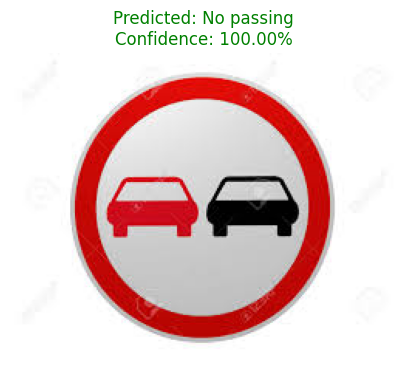

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Complete GTSRB Class Labels Dictionary
CLASSES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing veh over 3.5 tons'
}

# 2. Configuration - UPDATE THIS WITH YOUR IMAGE NAME
IMAGE_PATH = '/content/gtsb1.jpg'  # <-- Change this to your uploaded file name
MODEL_PATH = 'best_traffic_sign_model.h5'

def run_manual_inference(img_path, model_path):
    # Load the trained model
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Error loading model. Make sure '{model_path}' exists in your current directory.\nDetails: {e}")
        return

    # Load and check the raw image
    raw_img = cv2.imread(img_path)
    if raw_img is None:
        print(f"Error: Could not find or read the image at {img_path}. Verify the file name.")
        return

    # Convert from BGR (OpenCV default) to RGB for viewing and model consistency
    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # Preprocess image to match the custom CNN training pipeline
    img_resized = cv2.resize(img_rgb, (32, 32))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # Expand batch dimension (1, 32, 32, 3)

    # Execute Prediction
    predictions = model.predict(img_input)
    predicted_class_id = np.argmax(predictions, axis=-1)[0]
    confidence_score = np.max(predictions) * 100

    # Map ID to Human-Readable Label
    predicted_label = CLASSES.get(predicted_class_id, "Unknown Sign")

    # Display Results
    print("\n" + "="*40)
    print(f"PREDICTION: {predicted_label} (Class ID: {predicted_class_id})")
    print(f"CONFIDENCE: {confidence_score:.2f}%")
    print("="*40)

    # Plot the original image with prediction header
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence_score:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

# Run the test
run_manual_inference(IMAGE_PATH, MODEL_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step

PREDICTION: Yield (Class ID: 13)
CONFIDENCE: 26.69%


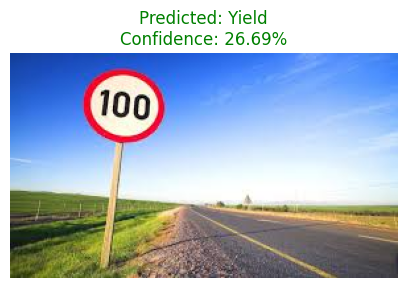

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Complete GTSRB Class Labels Dictionary
CLASSES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing veh over 3.5 tons'
}

# 2. Configuration - UPDATE THIS WITH YOUR IMAGE NAME
IMAGE_PATH = '/content/gtsb2.jpg'  # <-- Change this to your uploaded file name
MODEL_PATH = 'best_traffic_sign_model.h5'

def run_manual_inference(img_path, model_path):
    # Load the trained model
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Error loading model. Make sure '{model_path}' exists in your current directory.\nDetails: {e}")
        return

    # Load and check the raw image
    raw_img = cv2.imread(img_path)
    if raw_img is None:
        print(f"Error: Could not find or read the image at {img_path}. Verify the file name.")
        return

    # Convert from BGR (OpenCV default) to RGB for viewing and model consistency
    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # Preprocess image to match the custom CNN training pipeline
    img_resized = cv2.resize(img_rgb, (32, 32))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # Expand batch dimension (1, 32, 32, 3)

    # Execute Prediction
    predictions = model.predict(img_input)
    predicted_class_id = np.argmax(predictions, axis=-1)[0]
    confidence_score = np.max(predictions) * 100

    # Map ID to Human-Readable Label
    predicted_label = CLASSES.get(predicted_class_id, "Unknown Sign")

    # Display Results
    print("\n" + "="*40)
    print(f"PREDICTION: {predicted_label} (Class ID: {predicted_class_id})")
    print(f"CONFIDENCE: {confidence_score:.2f}%")
    print("="*40)

    # Plot the original image with prediction header
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence_score:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

# Run the test
run_manual_inference(IMAGE_PATH, MODEL_PATH)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 817ms/step

PREDICTION: General caution (Class ID: 18)
CONFIDENCE: 99.79%


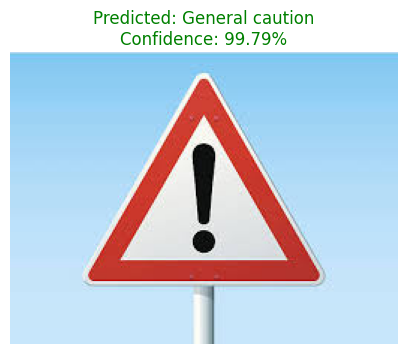

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Complete GTSRB Class Labels Dictionary
CLASSES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)',
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection',
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles',
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution',
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve',
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right',
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing',
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing',
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead',
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left',
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory',
    41: 'End of no passing', 42: 'End no passing veh over 3.5 tons'
}

# 2. Configuration - UPDATE THIS WITH YOUR IMAGE NAME
IMAGE_PATH = '/content/gtsb3.jpg'  # <-- Change this to your uploaded file name
MODEL_PATH = 'best_traffic_sign_model.h5'

def run_manual_inference(img_path, model_path):
    # Load the trained model
    try:
        model = tf.keras.models.load_model(model_path)
    except Exception as e:
        print(f"Error loading model. Make sure '{model_path}' exists in your current directory.\nDetails: {e}")
        return

    # Load and check the raw image
    raw_img = cv2.imread(img_path)
    if raw_img is None:
        print(f"Error: Could not find or read the image at {img_path}. Verify the file name.")
        return

    # Convert from BGR (OpenCV default) to RGB for viewing and model consistency
    img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # Preprocess image to match the custom CNN training pipeline
    img_resized = cv2.resize(img_rgb, (32, 32))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)  # Expand batch dimension (1, 32, 32, 3)

    # Execute Prediction
    predictions = model.predict(img_input)
    predicted_class_id = np.argmax(predictions, axis=-1)[0]
    confidence_score = np.max(predictions) * 100

    # Map ID to Human-Readable Label
    predicted_label = CLASSES.get(predicted_class_id, "Unknown Sign")

    # Display Results
    print("\n" + "="*40)
    print(f"PREDICTION: {predicted_label} (Class ID: {predicted_class_id})")
    print(f"CONFIDENCE: {confidence_score:.2f}%")
    print("="*40)

    # Plot the original image with prediction header
    plt.figure(figsize=(5, 5))
    plt.imshow(img_rgb)
    plt.title(f"Predicted: {predicted_label}\nConfidence: {confidence_score:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

# Run the test
run_manual_inference(IMAGE_PATH, MODEL_PATH)